In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# Load clean data
df = pd.read_csv('/Users/milindthapar/Desktop/portfolio/projects/superstore_clean.csv')

# Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'])

print(df.shape)
print(df.dtypes)
print(df.head())

(9994, 21)
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date                object
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object
   Row ID        Order ID Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08  2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08  2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12  2016-06-16    Second Clas

          ds           y
0 2014-01-01  14236.8950
1 2014-02-01   4519.8920
2 2014-03-01  55691.0090
3 2014-04-01  28295.3450
4 2014-05-01  23648.2870
5 2014-06-01  34595.1276
6 2014-07-01  33946.3930
7 2014-08-01  27909.4685
8 2014-09-01  81777.3508
9 2014-10-01  31453.3930
Total months: 48


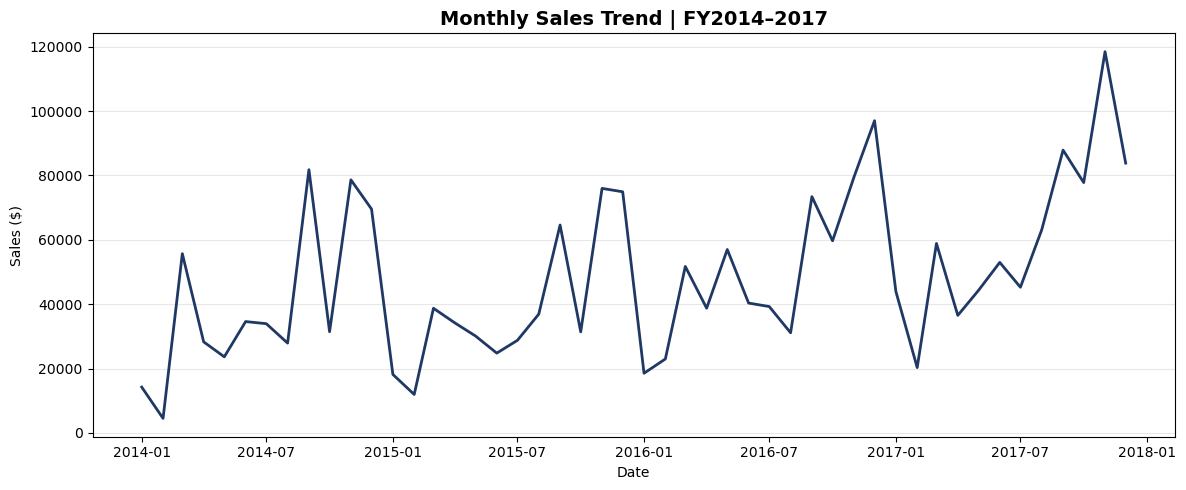

Chart saved


In [7]:
# Aggregate total sales by month
df_monthly = df.groupby(pd.Grouper(key='Order Date', freq='MS'))['Sales'].sum().reset_index()
df_monthly.columns = ['ds', 'y']

print(df_monthly.head(10))
print(f"Total months: {len(df_monthly)}")

# Plot historical sales trend
plt.figure(figsize=(12, 5))
plt.plot(df_monthly['ds'], df_monthly['y'], color='#1F3864', linewidth=2)
plt.title('Monthly Sales Trend | FY2014–2017', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=150)
plt.show()
print("Chart saved")

10:00:30 - cmdstanpy - INFO - Chain [1] start processing
10:00:31 - cmdstanpy - INFO - Chain [1] done processing


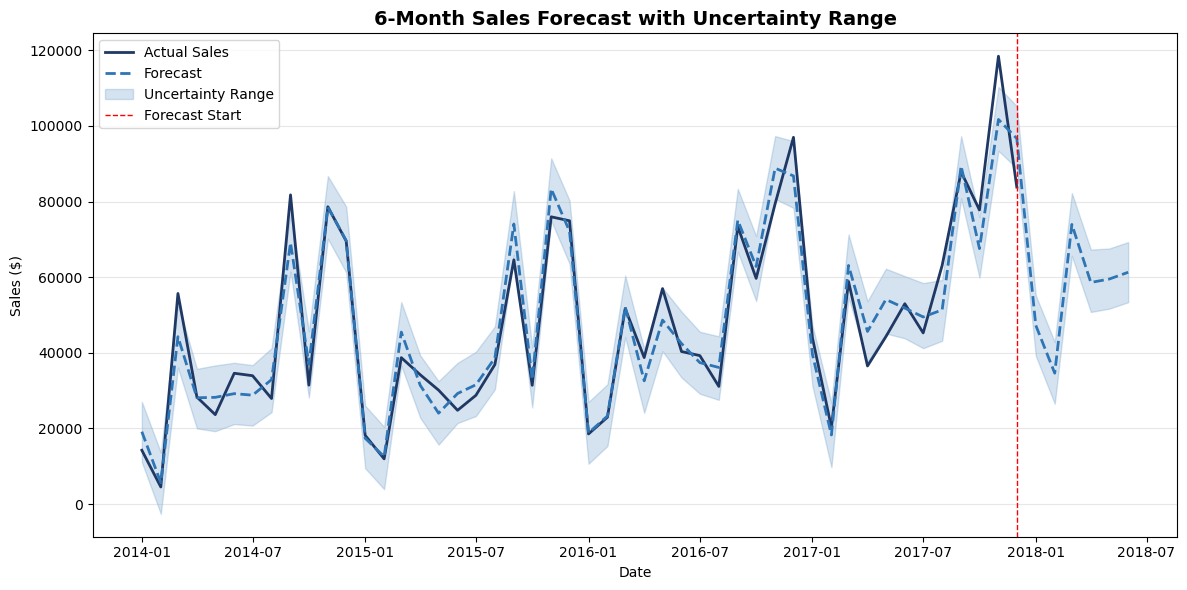


6-Month Forecast:
     Month  Base Forecast  Downside   Upside
2018-01-01       47286.50  39224.70 55190.92
2018-02-01       34616.64  26537.69 42839.87
2018-03-01       73956.70  65642.60 82259.99
2018-04-01       58612.57  50807.34 67303.20
2018-05-01       59508.76  51677.90 67590.64
2018-06-01       61301.58  53378.06 69284.49


In [9]:
# Fit Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1
)
model.fit(df_monthly)

# Forecast 6 months ahead
future = model.make_future_dataframe(periods=6, freq='MS')
forecast = model.predict(future)

# Plot forecast
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_monthly['ds'], df_monthly['y'], 
        color='#1F3864', linewidth=2, label='Actual Sales')
ax.plot(forecast['ds'], forecast['yhat'], 
        color='#2E75B6', linewidth=2, linestyle='--', label='Forecast')
ax.fill_between(forecast['ds'], 
                forecast['yhat_lower'], 
                forecast['yhat_upper'],
                alpha=0.2, color='#2E75B6', label='Uncertainty Range')
ax.axvline(x=df_monthly['ds'].max(), 
           color='red', linestyle='--', linewidth=1, label='Forecast Start')
ax.set_title('6-Month Sales Forecast with Uncertainty Range', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales ($)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('sales_forecast.png', dpi=150)
plt.show()

# Print forecast values
forecast_only = forecast[forecast['ds'] > df_monthly['ds'].max()][
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']].round(2)
forecast_only.columns = ['Month', 'Base Forecast', 'Downside', 'Upside']
print("\n6-Month Forecast:")
print(forecast_only.to_string(index=False))

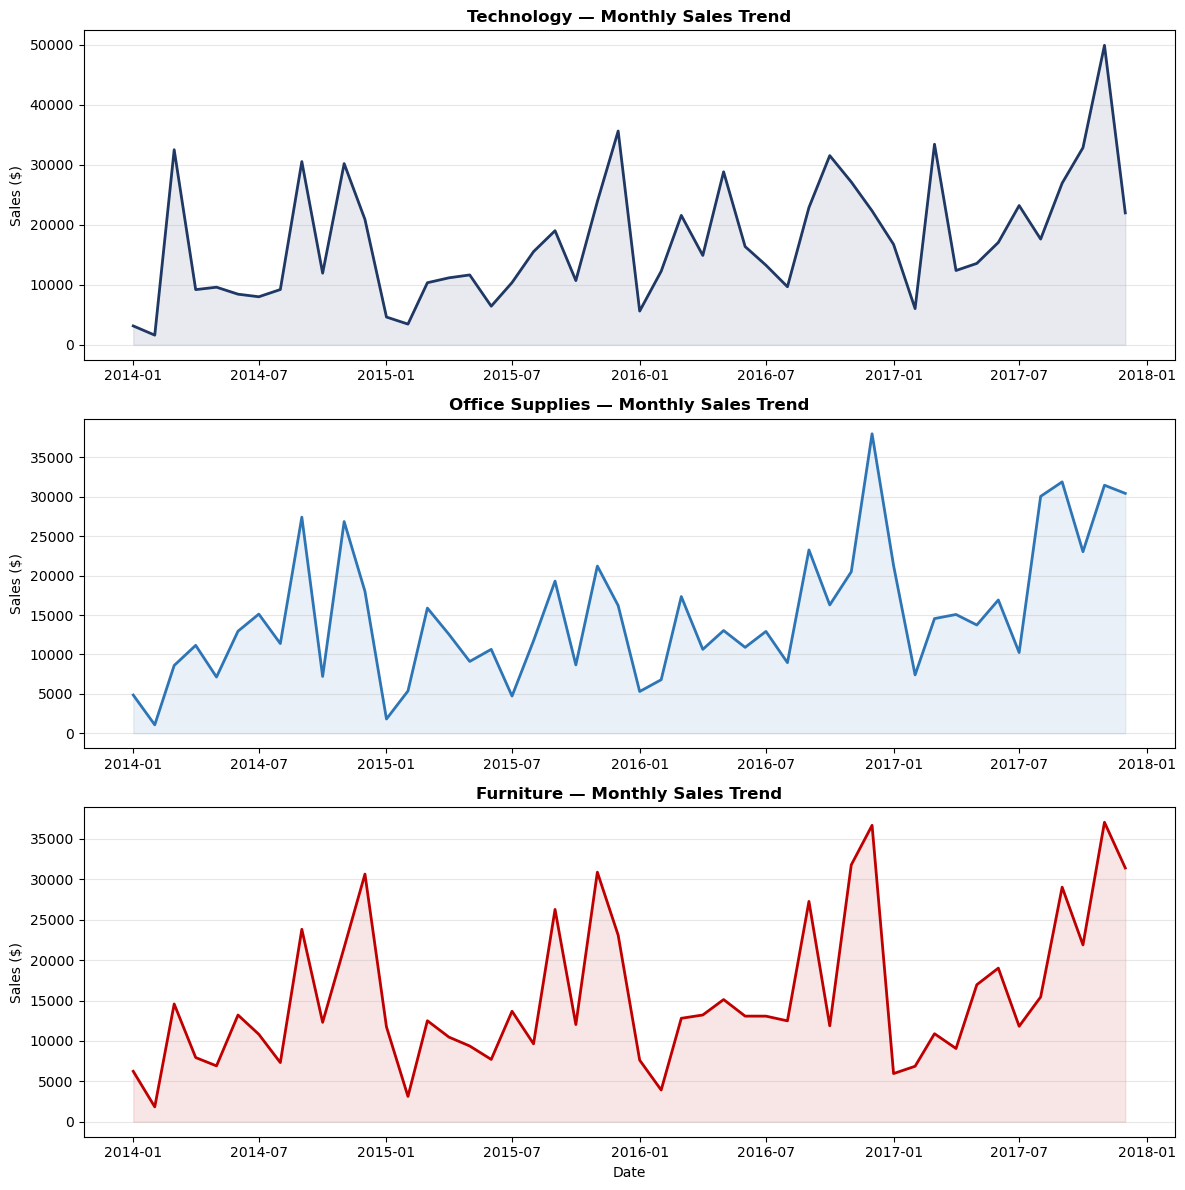

Category trends saved


In [11]:
# Category level monthly sales
df_cat = df.groupby([pd.Grouper(key='Order Date', freq='MS'), 'Category'])['Sales'].sum().reset_index()

# Plot category trends
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
categories = ['Technology', 'Office Supplies', 'Furniture']
colors = ['#1F3864', '#2E75B6', '#C00000']

for i, (cat, color) in enumerate(zip(categories, colors)):
    cat_data = df_cat[df_cat['Category'] == cat]
    axes[i].plot(cat_data['Order Date'], cat_data['Sales'], 
                color=color, linewidth=2)
    axes[i].set_title(f'{cat} — Monthly Sales Trend', 
                     fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Sales ($)')
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].fill_between(cat_data['Order Date'], 
                        cat_data['Sales'], alpha=0.1, color=color)

axes[2].set_xlabel('Date')
plt.tight_layout()
plt.savefig('category_trends.png', dpi=150)
plt.show()
print("Category trends saved")

In [13]:
# Build scenario planning table
scenarios = {
    'Month': ['Jan-18', 'Feb-18', 'Mar-18', 'Apr-18', 'May-18', 'Jun-18'],
    'Downside (-15%)': [39225, 26538, 65643, 50807, 51678, 53378],
    'Base Forecast': [47287, 34617, 73957, 58613, 59509, 61302],
    'Upside (+15%)': [55191, 42840, 82260, 67303, 67591, 69284]
}

df_scenarios = pd.DataFrame(scenarios)
df_scenarios['Downside (-15%)'] = df_scenarios['Downside (-15%)'].apply(lambda x: f"${x:,}")
df_scenarios['Base Forecast'] = df_scenarios['Base Forecast'].apply(lambda x: f"${x:,}")
df_scenarios['Upside (+15%)'] = df_scenarios['Upside (+15%)'].apply(lambda x: f"${x:,}")

print("\n=== 6-MONTH SCENARIO PLANNING TABLE ===")
print(df_scenarios.to_string(index=False))

total_base = 334285
total_down = 287272
total_up = 384469

print(f"\nTotal 6-Month Revenue:")
print(f"Downside Scenario:  ${total_down:,}")
print(f"Base Scenario:      ${total_base:,}")
print(f"Upside Scenario:    ${total_up:,}")


=== 6-MONTH SCENARIO PLANNING TABLE ===
 Month Downside (-15%) Base Forecast Upside (+15%)
Jan-18         $39,225       $47,287       $55,191
Feb-18         $26,538       $34,617       $42,840
Mar-18         $65,643       $73,957       $82,260
Apr-18         $50,807       $58,613       $67,303
May-18         $51,678       $59,509       $67,591
Jun-18         $53,378       $61,302       $69,284

Total 6-Month Revenue:
Downside Scenario:  $287,272
Base Scenario:      $334,285
Upside Scenario:    $384,469
